In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Variance on measurements of noise-diode and other calibrators

Notebook for testing the level of variance when attempting to measure the radiometric temperature of a source such as the noise-diode using the quatient

$$q = \frac{p_{\rm src} - p_{\rm L}}{p_{\rm NS} - p_{\rm L}} \approx \frac{T_{\rm src} - T_{\rm L}}{T_{\rm NS} - T_{\rm L}}$$

where the $\approx$ sign indicates the case of perfectly matched sources

This would be used in the equation

$$T_{\rm src} \approx (T_{\rm NS} - T_{\rm L}) q + T_{\rm L}$$

to calibrate out the $g$ and $T_0$ portions of the radiometer power contributions.

for perfectly matched sources.

In general

$$\left( \frac{\sigma_q}{q} \right)^2 = \frac{1}{\Delta\nu\tau} \left[ \frac{P_{\rm src}^2}{(P_{src} - P_{\rm L})^2} \frac{1}{\phi_{\rm src}} + \frac{P_{\rm NS}^2}{(P_{\rm NS} - P_{\rm L})^2} \frac{1}{\phi_{\rm NS}} + \frac{P_{\rm L}^2 \left(P_{\rm src} - P_{\rm NS}\right)^2}{\left( P_{\rm NS} - P_{\rm L} \right)^2 \left( P_{\rm src} - P_{\rm L} \right)^2 } \frac{1}{\phi_{\rm L}} \right]$$

If $p_{\rm i} = g(T_{\rm i} (1 - |\Gamma_{\rm rec}|^2) + T_0)$

where $i \in \{NS, L, ND\}$ where ND is specifically the noise diode and NS is the heated load


The variance on measurements of $T_{\rm src}$ can be given by

$$ \sigma_{T_{\rm src}}^2  = \frac{(T_{\rm NS} - T_{\rm L})^2}{\delta \nu \tau} \left[ 
    \frac{p_{\rm src}^2}{(p_{\rm NS} - p_{\rm L})^2} \frac{1}{\phi_{\rm src}} +
    \frac{p_{\rm NS}^2 (p_{\rm src} - p_{\rm L})^2}{(p_{\rm NS} - p_{\rm L})^4} \frac{1}{\phi_{\rm NS}} +
    \frac{p_{\rm L}^2 (p_{\rm src} - p_{\rm NS})^2}{(p_{\rm NS} - p_{\rm L})^4} \frac{1}{\phi_{\rm L}}
\right] $$

For now, lets assume that $\phi_i = 1/3$

In [3]:
def dB_to_lin(dB):
    return 10**(dB / 10)

def compute_radiometer_power(T_src,
                             T_unc,
                             T_sin,
                             T_cos,
                             T_0,
                             Gamma_rec,
                             Gamma_src,
                             gain=1000,
                             delta_nu=1e4):
    
    F_src = np.sqrt(1 - (np.abs(Gamma_rec)**2)) / (1 - (Gamma_rec*Gamma_src))

    p_src = gain * delta_nu *  ((T_src * (1 - (np.abs(Gamma_src)**2)) * np.abs(F_src)**2) + \
                    (T_unc * np.abs(Gamma_src)**2 * np.abs(F_src)**2) + \
                    (T_cos * np.real(Gamma_src * F_src)) + \
                    (T_sin * np.imag(Gamma_src * F_src)) + \
                    T_0)

    return p_src
    
def t_src_var(T_ns,
              T_l,
              T_src,
              T_0,
              T_unc,
              T_cos,
              T_sin,
              gamma_rec,
              gamma_src = 0,
              gamma_l = 0,
              gamma_ns = 0,
              g=1000,
              delta_nu = 20e6 / 8192,
              tau = 60,
              phi_src=1/3,
              phi_l=1/3,
              phi_ns=1/3):
    p_src = compute_radiometer_power(T_src, T_unc, T_sin,
                                     T_cos, T_0, gamma_rec,
                                     gamma_src, g, delta_nu)
    p_l = compute_radiometer_power(T_l, T_unc, T_sin,
                                     T_cos, T_0, gamma_rec,
                                     gamma_l, g, delta_nu)
    p_ns = compute_radiometer_power(T_ns, T_unc, T_sin,
                                     T_cos, T_0, gamma_rec,
                                     gamma_ns, g, delta_nu)
    
    multiplier = np.power(T_ns - T_l, 2) / (delta_nu * tau)

    src_term = np.power(p_src, 2) / (np.power(p_ns - p_l, 2)*phi_src)

    ns_term = np.power(p_ns, 2) * np.power(p_src - p_l, 2) / (np.power(p_ns - p_l, 4)*phi_ns)

    l_term = np.power(p_l, 2) * np.power(p_src - p_ns, 2) / (np.power(p_ns - p_l, 4)*phi_l)

    return multiplier * (src_term + ns_term + l_term)

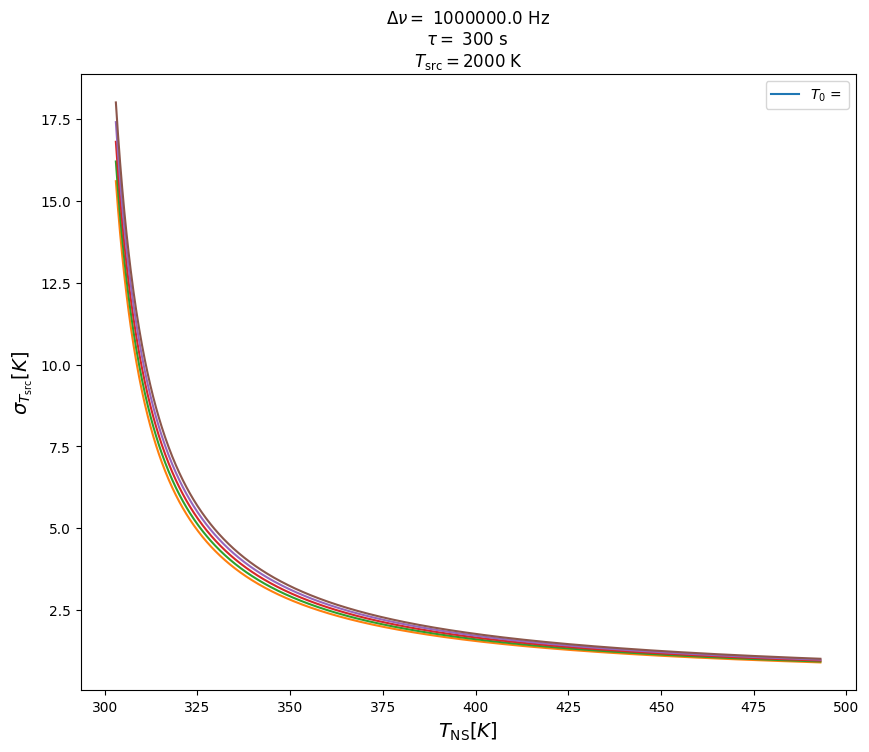

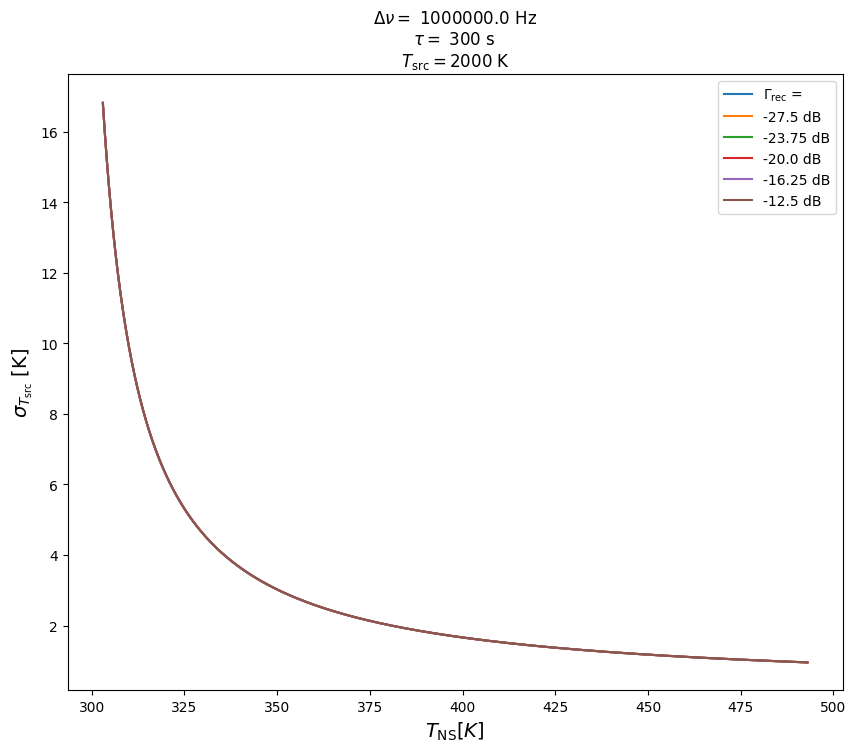

250.0
[0.23053268 0.22314569 0.21614642 0.20950773 0.20320484 0.19721508
 0.19151768 0.18609355 0.18092517 0.17599642 0.17129241 0.16679942
 0.16250476 0.15839669 0.15446434 0.15069762 0.14708716 0.14362425
 0.14030078 0.13710921 0.13404249 0.13109404 0.12825773 0.1255278
 0.12289888 0.12036592 0.11792421 0.1155693  0.11329703 0.11110348
 0.10898496 0.106938   0.10495934 0.10304589 0.10119474 0.09940315
 0.09766851 0.09598838 0.09436043 0.09278247 0.0912524  0.08976827
 0.08832819 0.0869304  0.08557319 0.08425498 0.08297423 0.08172951
 0.08051942 0.07934266 0.07819799 0.07708419 0.07600015 0.07494478
 0.07391705 0.07291596 0.07194057 0.07098999 0.07006336 0.06915984
 0.06827865 0.06741904 0.06658029 0.0657617  0.06496261 0.06418238
 0.06342041 0.06267611 0.06194892 0.0612383  0.06054373 0.05986471
 0.05920078 0.05855146 0.05791632 0.05729494 0.0566869  0.0560918
 0.05550928 0.05493897 0.05438051 0.05383357 0.05329782 0.05277294
 0.05225863 0.05175461 0.05126058 0.05077627 0.05030142 0.

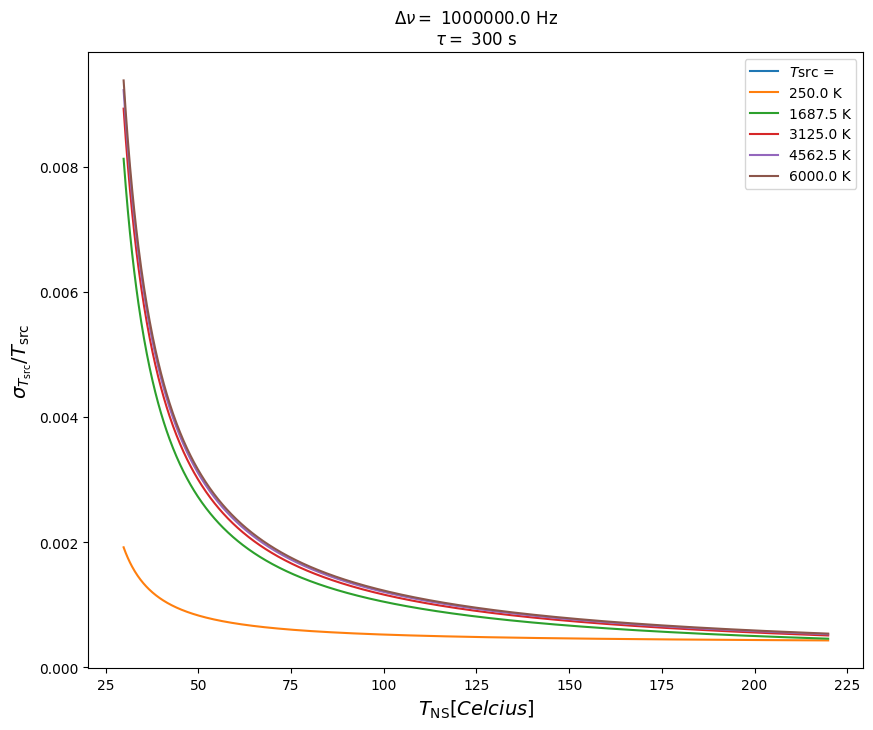

250.0
[0.26588994 0.25728259 0.24912796 0.24139433 0.23405275 0.2270767
 0.2204419  0.21412607 0.20810873 0.20237101 0.19689555 0.1916663
 0.18666845 0.18188828 0.17731308 0.17293107 0.16873132 0.16470364
 0.16083857 0.15712729 0.15356158 0.15013377 0.14683667 0.14366358
 0.14060822 0.13766472 0.13482754 0.13209151 0.12945178 0.12690376
 0.12444316 0.12206592 0.11976824 0.11754651 0.11539735 0.11331754
 0.11130405 0.10935404 0.10746477 0.1056337  0.1038584  0.10213656
 0.100466   0.09884464 0.09727053 0.0957418  0.09425666 0.09281342
 0.0914105  0.09004634 0.0887195  0.08742859 0.08617228 0.08494931
 0.08375848 0.08259864 0.08146868 0.08036757 0.07929429 0.07824788
 0.07722744 0.07623208 0.07526095 0.07431326 0.07338822 0.07248511
 0.07160321 0.07074184 0.06990035 0.0690781  0.0682745  0.06748897
 0.06672096 0.06596992 0.06523534 0.06451673 0.06381362 0.06312555
 0.06245206 0.06179275 0.0611472  0.06051502 0.05989582 0.05928925
 0.05869495 0.05811257 0.05754179 0.05698229 0.05643376 0.

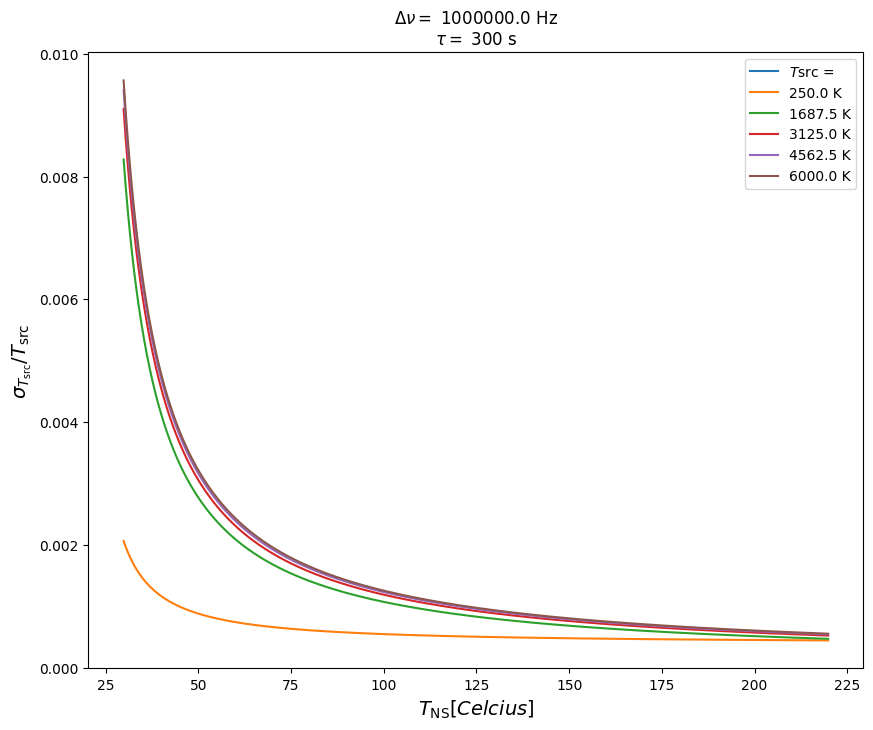

In [9]:
T_0 = 400 # K
GAMMA_REC_DB = -20
GAMMA_REC = dB_to_lin(GAMMA_REC_DB)
T_unc = 300
T_sin = 20
T_cos = 20
DELTA_NU = 1e6
TAU = 300
g = 1000

T_L = 293
T_src = 2000


t_ns = np.linspace(293+10, 293+200, 1000)


n_steps = 5
T_0_span = 100
gamma_rec_span_db = 15 # pm dB

t_src_array = np.linspace(250, 6000, n_steps)

T_0_array = np.linspace(T_0 - (T_0_span/2),
                        T_0 + (T_0_span/2),
                        n_steps)

plt.plot([],[], label=r'$T_0$ = ')
for t_0 in T_0_array:
    t_src_var_array = t_src_var(T_ns=t_ns,
                                T_l=T_L,
                                T_src=T_src,
                                T_0=t_0,
                                T_unc=T_unc,
                                T_cos=T_cos,
                                T_sin=T_sin,
                                gamma_rec=GAMMA_REC,
                                delta_nu=DELTA_NU,
                                tau=TAU)
    
    plt.plot(t_ns, np.sqrt(t_src_var_array))#,
             #label=f"{t_0} K")
plt.ylabel(r'$\sigma_{T_{\rm src}} [K]$', fontsize=14)
plt.xlabel(r'$T_{\rm NS} [K]$', fontsize=14)
plt.gcf().set_size_inches((10.,8))
plt.title(r'$\Delta \nu = $'+f' {DELTA_NU} Hz \n' +\
          r'$\tau = $'+f' {TAU} s \n'\
            + r'$T_{\rm src} =$' + f'{T_src} K')
plt.legend()
plt.show()


gamma_array_dB = np.linspace(GAMMA_REC_DB - (gamma_rec_span_db/2),
                        GAMMA_REC_DB + (gamma_rec_span_db/2),
                        n_steps)
gamma_lin_array = dB_to_lin(gamma_array_dB)


plt.plot([],[], label=r'$\Gamma_{\rm rec}$ = ')
for gamma_rec in gamma_lin_array:
    t_src_var_array = t_src_var(T_ns=t_ns,
                                T_l=T_L,
                                T_src=T_src,
                                T_0=T_0,
                                T_unc=T_unc,
                                T_cos=T_cos,
                                T_sin=T_sin,
                                gamma_rec=gamma_rec,
                                delta_nu=DELTA_NU,
                                tau=TAU)
    
    plt.plot(t_ns, np.sqrt(t_src_var_array),
             label=f"{10*np.log10(gamma_rec)} dB")
plt.ylabel(r'$\sigma_{T_{\rm src}}$ [K]', fontsize=14)
plt.xlabel(r'$T_{\rm NS} [K]$', fontsize=14)
plt.gcf().set_size_inches((10.,8))
plt.title(r'$\Delta \nu = $'+f' {DELTA_NU} Hz \n' +\
          r'$\tau = $'+f' {TAU} s \n'\
            + r'$T_{\rm src} =$' + f'{T_src} K')
plt.legend()
plt.show()


plt.plot([],[], label=r'$T{\rm src}$ = ')
for t_src in t_src_array:
    t_src_var_array = t_src_var(T_ns=t_ns,
                                T_l=T_L,
                                T_src=t_src,
                                T_0=T_0,
                                T_unc=T_unc,
                                T_cos=T_cos,
                                T_sin=T_sin,
                                gamma_rec=GAMMA_REC,
                                delta_nu=DELTA_NU,
                                tau=TAU)
    print(t_src)
    print(t_src_var_array)

    plt.plot(t_ns - 273.15, np.sqrt(t_src_var_array) / t_src,
             label=f"{t_src} K")
plt.ylabel(r'$\sigma_{T_{\rm src}} / T_{\rm src}$', fontsize=14)
plt.xlabel(r'$T_{\rm NS} [Celcius]$', fontsize=14)
plt.gcf().set_size_inches((10.,8))
plt.title(r'$\Delta \nu = $'+f' {DELTA_NU} Hz \n' +\
          r'$\tau = $'+f' {TAU} s'
          )
plt.legend()
plt.show()


plt.plot([],[], label=r'$T{\rm src}$ = ')
for t_src in t_src_array:
    t_src_var_array = t_src_var(T_ns=t_ns,
                                T_l=T_L,
                                T_src=t_src,
                                T_0=T_0,
                                T_unc=T_unc,
                                T_cos=T_cos,
                                T_sin=T_sin,
                                gamma_rec=GAMMA_REC,
                                delta_nu=DELTA_NU,
                                tau=TAU,
                                gamma_ns=dB_to_lin(-10),
                                gamma_l=dB_to_lin(-10))
    print(t_src)
    print(t_src_var_array)

    plt.plot(t_ns - 273.15, np.sqrt(t_src_var_array) / t_src,
             label=f"{t_src} K")
plt.ylabel(r'$\sigma_{T_{\rm src}} / T_{\rm src}$', fontsize=14)
plt.xlabel(r'$T_{\rm NS} [Celcius]$', fontsize=14)
plt.gcf().set_size_inches((10.,8))
plt.title(r'$\Delta \nu = $'+f' {DELTA_NU} Hz \n' +\
          r'$\tau = $'+f' {TAU} s'
          )
plt.legend()
plt.show()